# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is considered linear because it is linear in its coefficients (parameters), not necessarily in the variables themselves. In a linear regression model, the outcome is written as a weighted sum of the features plus an intercept. For example, y=β_0 + β_1x_1 + β_2x_2+ ... +β_p_x_p. The key property is that the coefficients β appear only as linear terms (they are not multiplied by each other or inside nonlinear functions). Even if the features themselves are transformed (such as x^2 or log x), the model is still considered linear as long as it is linear in the coefficients.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

A dummy variable represents membership in a category and takes values of 0 or 1. The coefficient for a dummy variable represents the difference in the predicted outcome compared to the reference group, holding all other variables constant. The reference group is the category that was omitted to avoid perfect multicollinearity with the intercept. If the dummy variable equals 1, the predicted value of the outcome increases or decreases by the size of the coefficient relative to the baseline category represented by the intercept.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can technically be used for classification by predicting numeric values and then applying a threshold (for example, predicting class 1 if the prediction is greater than 0.5). However, it is generally not appropriate for classification problems because it can produce predictions outside the range of valid probabilities (less than 0 or greater than 1). Additionally, linear regression assumes normally distributed errors and continuous outcomes, which do not match the structure of categorical data. For classification tasks, models like logistic regression are usually preferred because they constrain predictions to the range of valid probabilities.

4. What are signs that your linear model is over-fitting?

A major sign of overfitting is when the model performs very well on the training data but poorly on the test data. This indicates that the model has memorized patterns specific to the training dataset rather than learning general relationships. Other signs include extremely large or unstable coefficients, high model complexity relative to the amount of data, and predictions that fluctuate strongly with small changes in the dataset.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity occurs when two or more explanatory variables are highly correlated, making it difficult to estimate their individual effects. This leads to unstable coefficient estimates and large standard errors. One way to understand this is through a two-stage approach: first, regress one explanatory variable on the others to isolate the portion that is independent of them. If little independent variation remains, it indicates strong multicollinearity. As a result, the regression struggles to distinguish the separate impact of correlated variables.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Nonlinear relationships can be incorporated by transforming the input features before fitting the model. For example, we can include polynomial terms such as x^2 or x^3, interaction terms between variables, or transformations like logarithms or square roots. Even though these transformations capture nonlinear relationships between the variables, the regression model remains linear in the coefficients.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient represents the expected change in the outcome variable y for a one-unit increase in the corresponding feature x, holding all other variables in the model constant. In other words, it measures how strongly that particular feature is associated with changes in the predicted value of the outcome.

8. Compare the train/test split and $k$-fold cross validation.

A train/test split divides the dataset into two parts: a training set used to fit the model and a test set used to evaluate performance. This method is simple but the results can depend on how the data was split.

k-fold cross validation is a more robust approach where the data is divided into
𝑘 equal parts. The model is trained
k times, each time leaving out one fold for testing and using the remaining folds for training. The performance is then averaged across all folds. This approach uses more of the data for evaluation and typically produces a more stable estimate of model performance.

9. How is the $k$ in $k$-fold cross validation typically selected?

The value of k is usually chosen based on a tradeoff between computational cost and stability of the performance estimate. Common choices are 5-fold or 10-fold cross validation. Larger values of k use more data for training and provide a more accurate estimate of model performance, but they require more computation.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [115]:
import pandas as pd

df = pd.read_csv('sample_data/Q1_clean.csv')

df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [116]:
df.columns = df.columns.str.strip()

In [117]:
df.groupby("Neighbourhood")[["Price","Review Scores Rating"]].mean()

,Price,Review Scores Rating
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


2.1
Manhattan has the highest average nightly price at approximately 183.66, making it the most expensive borough on average. Staten Island is the second most expensive at about 146.17, followed by Brooklyn at 127.75. Queens and the Bronx have the lowest average prices. The review scores are very similar across boroughs, all around 91–92, suggesting that ratings do not vary much by neighborhood.

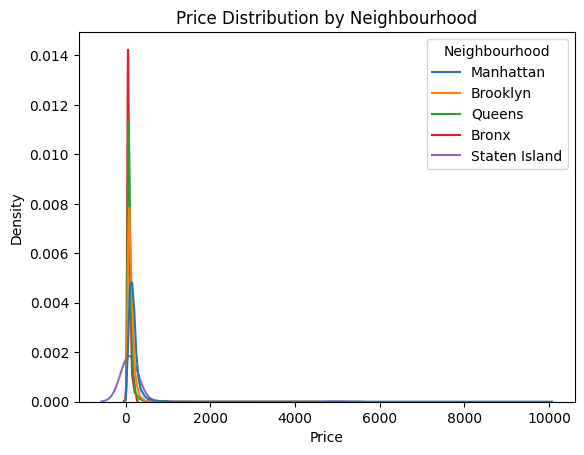

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df,
    x="Price",
    hue="Neighbourhood",
    common_norm=False
)

plt.title("Price Distribution by Neighbourhood")
plt.show()

The price distributions are highly right-skewed, meaning that most listings are relatively inexpensive while a small number of listings have extremely high prices. This causes the density curves to be concentrated near lower prices while the x-axis extends far to the right due to expensive outliers.

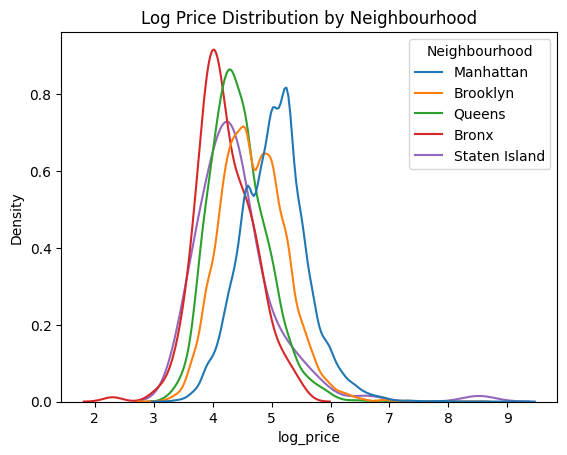

In [119]:
import numpy as np

df["log_price"] = np.log(df["Price"])

sns.kdeplot(
    data=df,
    x="log_price",
    hue="Neighbourhood",
    common_norm=False
)

plt.title("Log Price Distribution by Neighbourhood")
plt.show()

After applying a log transformation, the price distributions become more symmetric and less skewed. The transformation compresses the right tail, reducing the influence of extreme high-price listings. This makes differences across neighbourhoods easier to compare. Manhattan listings tend to have higher log prices, while Bronx listings tend to have the lowest.

In [120]:
import statsmodels.api as sm

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)

X = sm.add_constant(dummies)
y = df["Price"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:36:47   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

2.2
The intercept represents the average price in the reference borough (Bronx), which is approximately 75.28 per night. The Brooklyn coefficient indicates that listings in Brooklyn cost approximately 52.47 more per night on average than listings in the Bronx.Listings in Manhattan cost about 108.39 more per night on average than listings in the Bronx.

The regression coefficients exactly reproduce the differences in group means from part 1, since OLS with dummies and an intercept estimates conditional means. The intercept corresponds to the mean price of the reference group, while each dummy variable coefficient measures how much higher or lower the average price is compared to that reference group.

R^2 value is 0.46, meaning that only 4.6% of price variation is explained by borough. The R² value is relatively small, suggesting that neighborhood alone explains only a small portion of the variation in listing prices.

In [121]:
X = sm.add_constant(df["Review Scores Rating"])
y = df["Price"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        17:36:47   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

2.3
The coefficient for Review Scores Rating is approximately 1.02. This means that for each one-point increase in the review score rating, the expected listing price increases by about 1.02 per night on average.

Since review scores typically range between 60 and 100, the intercept represents the predicted price when the review score is zero, which is outside the observed range and therefore not meaningful.

The R² value is very small (0.004), indicating that review scores explain very little of the variation in listing prices.

Although the relationship is statistically significant, the very small R² suggests that review scores are not a strong predictor of listing price.

In [122]:
import pandas as pd
import statsmodels.api as sm

# Ensure numeric
df["Review Scores Rating"] = pd.to_numeric(df["Review Scores Rating"], errors="coerce")

# Dummies
dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)

# Interaction terms (IMPORTANT: rename columns)
interaction = dummies.mul(df["Review Scores Rating"], axis=0)
interaction.columns = [col + "_interaction" for col in interaction.columns]

# Combine
X = pd.concat([dummies, df["Review Scores Rating"], interaction], axis=1)

# Convert to float
X = X.astype(float)

# Add constant
X = sm.add_constant(X)

# Outcome
y = df["Price"]

# Fit
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:36:47   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

2.4
When allowing the effect of review scores to vary by neighbourhood, the relationship between review scores and price differs across boroughs. The baseline slope (Bronx) is relatively small, while boroughs like Manhattan and Brooklyn show a stronger positive relationship between review scores and price. In contrast, Queens shows a weaker relationship, and Staten Island exhibits an unstable and negative estimate, likely due to limited data or multicollinearity. Overall, this suggests that the impact of review scores on price is not constant across neighbourhoods, but varies depending on location.Additionally, the coefficient on review scores decreases slightly after controlling for neighbourhood, suggesting that some of the relationship between review scores and price was confounded by location.

In [123]:
dummies = pd.get_dummies(df["Neighbourhood"])

interaction = dummies.mul(df["Review Scores Rating"], axis=0)

X = sm.add_constant(interaction)
y = df["Price"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Tue, 17 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        17:36:47   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            55.1183     10.181      5.414

2.5
When separate slope coefficients are estimated for each neighborhood, the relationship between review scores and price differs somewhat across boroughs. The slopes range from about 0.22 in the Bronx to about 1.40 in Manhattan. This indicates that higher review scores are associated with higher prices in most neighborhoods, but the strength of this relationship varies. In particular, the relationship appears strongest in Manhattan and weaker in neighborhoods like the Bronx and Queens. This indicates that the relationship between review scores and price is heterogeneous across neighbourhoods.

In [124]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X4 = pd.get_dummies(df["Neighbourhood"], drop_first=True)
y = df["Price"]

model = LinearRegression()

scores4 = cross_val_score(model, X4, y, cv=10, scoring="r2")

print("Model 4 CV R2:", scores4.mean())

Model 4 CV R2: 0.04870843045967836


In [125]:
X5 = df[["Review Scores Rating"]]

scores5 = cross_val_score(model, X5, y, cv=10, scoring="r2")

print("Model 5 CV R2:", scores5.mean())

Model 5 CV R2: 0.0005052921079948036


In [126]:
X6 = pd.concat([X4, df[["Review Scores Rating"]]], axis=1)

scores6 = cross_val_score(model, X6, y, cv=10, scoring="r2")

print("Model 6 CV R2:", scores6.mean())

Model 6 CV R2: 0.053995295442938365


2.6
Cross-validation (10-fold) was used to evaluate the predictive performance of the three models. The model using only Review Scores Rating performed the worst, with a cross-validated R² close to zero, indicating that review scores alone have almost no predictive power for price.

The model using Neighbourhood performed substantially better, with a cross-validated R² of about 0.049, suggesting that location explains some variation in listing prices.

The model including both Neighbourhood and Review Scores Rating achieved the highest cross-validated R² (about 0.054), but the improvement over using Neighbourhood alone is small.

This indicates that Neighbourhood is the primary driver of price, while Review Scores Rating adds only marginal predictive value. Overall, location matters much more than review scores in determining listing prices.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [127]:
import pandas as pd

df = pd.read_csv("/content/sample_data/cars_hw.csv")
df = df.drop(columns=["Unnamed: 0"])
df.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [128]:
df["Price"].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


3.1
The average car price in the dataset is approximately 741,019 rupees, with a standard deviation of about 367,323 rupees, indicating substantial variation in prices. Prices range from 188,000 rupees to 2,941,000 rupees, suggesting the presence of both relatively inexpensive and high-end vehicles.

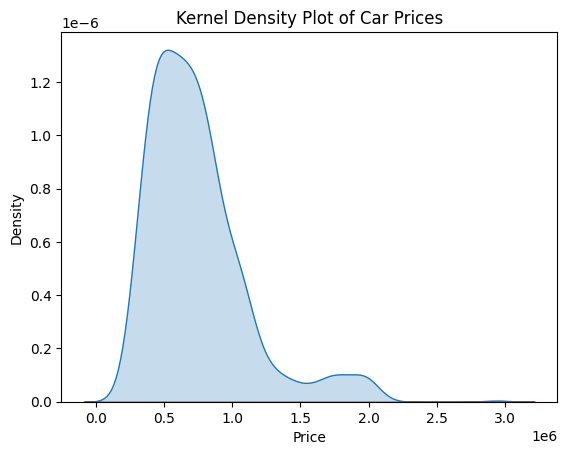

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df["Price"], fill=True)

plt.title("Kernel Density Plot of Car Prices")
plt.xlabel("Price")
plt.ylabel("Density")

plt.show()

The kernel density plot shows that most car prices fall between roughly 400,000 and 900,000 rupees, with a right-skewed distribution indicating a small number of higher-priced vehicles.

In [130]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


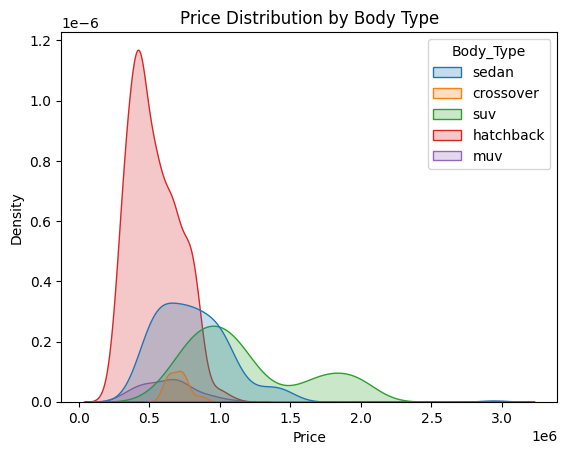

In [131]:
sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=True)

plt.title("Price Distribution by Body Type")
plt.xlabel("Price")

plt.show()

The kernel density plot of price by body type shows clear differences in price distributions across vehicle categories. Hatchbacks tend to have the lowest prices, with most observations concentrated between roughly 300,000 and 600,000 rupees. Sedans and MUVs occupy a middle range of prices, while SUVs have the highest prices overall, with many observations exceeding 1,000,000 rupees. SUVs also exhibit the widest distribution, indicating greater variability in prices compared to other body types. This visualization confirms that SUVs are generally the most expensive category of vehicles in the dataset.

In [132]:
from sklearn.linear_model import LinearRegression

X = df[["Seating_Capacity"]]
y = df["Price"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: 439032.0141018266
Slope: 59267.99803672175


3.2
Regressing price on seating capacity produces a slope coefficient of approximately 59,268. This means that each additional seat is associated with an average increase in price of about 59,268 rupees. The intercept of approximately 439,032 represents the predicted price when seating capacity is zero, which does not have a practical interpretation but serves as the baseline for the regression line.

In [133]:
X_cat = pd.get_dummies(df["Seating_Capacity"], prefix="seat", drop_first=True)

model_cat = LinearRegression()
model_cat.fit(X_cat, y)

print("Intercept:", model_cat.intercept_)
print("Coefficients:", dict(zip(X_cat.columns, model_cat.coef_)))

Intercept: 188000.00000000314
Coefficients: {'seat_5': np.float64(546483.8709677386), 'seat_6': np.float64(1455999.9999999998), 'seat_7': np.float64(735948.7179487164), 'seat_8': np.float64(271799.999999999)}


Regressing price on seating capacity yields a slope coefficient of approximately 59,268, meaning that each additional seat is associated with an average increase of about 59,268 rupees in price. When seating capacity is treated as a categorical variable using one-hot encoding, the regression estimates separate price differences for each seating category relative to the baseline group. These estimated differences vary substantially across seating categories and do not increase consistently with the number of seats. This suggests that the relationship between seating capacity and price is not strictly linear, and that treating seating capacity as a categorical variable may better capture differences in pricing across vehicle types.

In [134]:
df["Age"] = 2025 - df["Make_Year"]
df[["Make_Year","Age"]].head()

,Make_Year,Age
0,2017,8
1,2016,9
2,2019,6
3,2017,8
4,2017,8


In [135]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np

y = df["Price"]

results = {}

for degree in range(1,6):

    poly = PolynomialFeatures(degree)
    X_poly = poly.fit_transform(df[["Age"]])

    model = LinearRegression()

    scores = cross_val_score(model, X_poly, y, cv=10, scoring="r2")

    results[degree] = scores.mean()

print(results)

{1: np.float64(0.2054391565742792), 2: np.float64(0.20457001625643984), 3: np.float64(0.20679554482904922), 4: np.float64(0.20072321783312969), 5: np.float64(0.19704777544206126)}


3.3
A new variable Age was created by subtracting the vehicle's Make_Year from 2025. Polynomial regressions of Price on Age were estimated using powers of Age from 1 through 5. Ten-fold cross-validation was used to evaluate predictive performance for each model. The model with three powers of Age produced the highest cross-validated R², indicating that a cubic relationship between Age and Price provides the best predictive accuracy among the models considered. Higher-order polynomials produced lower cross-validated performance, suggesting potential overfitting.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


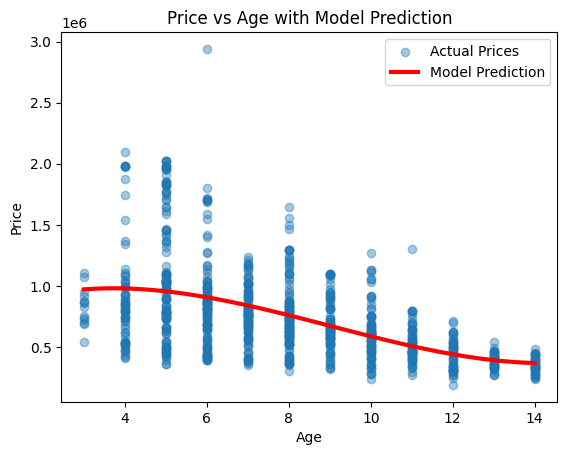

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Prepare polynomial features using the optimal degree (3)
poly = PolynomialFeatures(3)
X_poly = poly.fit_transform(df[["Age"]])

# Fit the model
model = LinearRegression()
model.fit(X_poly, df["Price"])

# Create smooth age values for prediction
age_range = np.linspace(df["Age"].min(), df["Age"].max(), 100).reshape(-1,1)
age_poly = poly.transform(age_range)

predicted_price = model.predict(age_poly)

# Plot
plt.scatter(df["Age"], df["Price"], alpha=0.4, label="Actual Prices")
plt.plot(age_range, predicted_price, color="red", linewidth=3, label="Model Prediction")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Prediction")
plt.legend()

plt.show()

3.4
The scatter plot of Price against Age shows that vehicle prices generally decline as cars get older. The model-predicted curve captures this overall downward trend, indicating that the polynomial regression successfully models the relationship between Age and Price. However, there is substantial variability in prices at each age level, as shown by the wide spread of points around the predicted curve. This suggests that while Age explains part of the variation in price, other factors such as vehicle type, mileage, and brand also influence the price of a car.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [137]:
df = pd.read_csv("/content/sample_data/heart_hw.csv")
df = df.drop(columns=["Unnamed: 0"])
df.head()

,age,transplant,y
0,53,control,0
1,43,control,0
2,52,control,0
3,52,control,0
4,54,control,0


In [138]:
df.groupby("transplant")["y"].mean()

,y
transplant,
control,0.117647
treatment,0.347826


4.1
The proportion of individuals who survive three years in the control group is 0.118, while the survival rate in the treatment group is 0.348. The average treatment effect (ATE) is 0.230, meaning that receiving a heart transplant increases the probability of surviving three years by about 23 percentage points.

In [139]:
df["transplant_dummy"] = (df["transplant"] == "treatment").astype(int)

import statsmodels.api as sm

X = sm.add_constant(df["transplant_dummy"])
y = df["y"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 17 Mar 2026   Prob (F-statistic):             0.0133
Time:                        17:36:48   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

4.2
In the regression of y on transplant with a constant, the intercept is approximately 0.118, which represents the survival probability for the control group. The coefficient on transplant is approximately 0.230, which represents the difference in survival rates between the treatment and control groups. This matches the average treatment effect (ATE) computed in part 1.

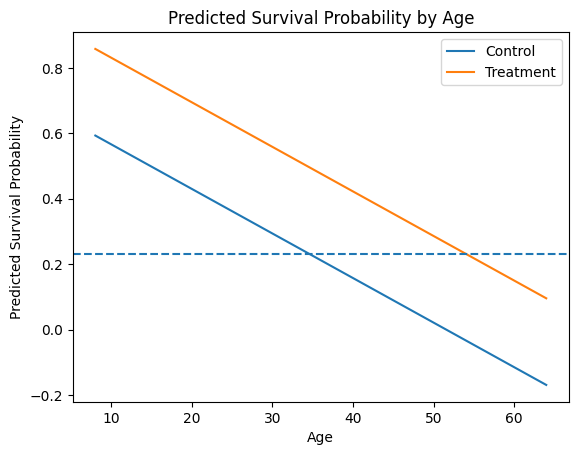

In [140]:
# model
X2 = sm.add_constant(df[["transplant_dummy", "age"]])
model2 = sm.OLS(y, X2).fit()

# smooth range
age_range = np.linspace(df["age"].min(), df["age"].max(), 100)

# predictions (MATCH EXACT COLUMN ORDER)
pred_control = model2.predict(pd.DataFrame({
    "const": 1,
    "transplant_dummy": 0,
    "age": age_range
}))

pred_treatment = model2.predict(pd.DataFrame({
    "const": 1,
    "transplant_dummy": 1,
    "age": age_range
}))

# plot
plt.plot(age_range, pred_control, label="Control")
plt.plot(age_range, pred_treatment, label="Treatment")

plt.axhline(ATE, linestyle="--")
plt.legend()
plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.title("Predicted Survival Probability by Age")
plt.show()

4.3
When age is included in the regression, the coefficient on transplant increases from about 0.23 to about 0.265. This suggests that age was confounding the relationship between transplant status and survival, and controlling for age reveals a slightly larger effect of receiving a transplant. The intercept represents the predicted survival probability for a control patient at age 0, which is not practically meaningful but serves as a baseline in the model., while the age coefficient indicates that survival probability decreases by about 1.36 percentage points for each additional year of age. The transplant coefficient represents the increase in survival probability associated with receiving a transplant while holding age constant.

Comparing the predicted survival probabilities to the average treatment effect from part 1 shows that the treatment effect is constant across all ages, as indicated by the parallel lines. Therefore, the ATE does not overestimate or underestimate the effect for any specific age group and accurately reflects the difference in survival between treatment and control.

In [141]:
df["transplant_age"] = df["transplant_dummy"] * df["age"]

X3 = sm.add_constant(df[["transplant_dummy", "age", "transplant_age"]])
y = df["y"]

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           0.000310
Time:                        17:36:48   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

In [142]:
df["predicted_interaction"] = model3.predict(X3)

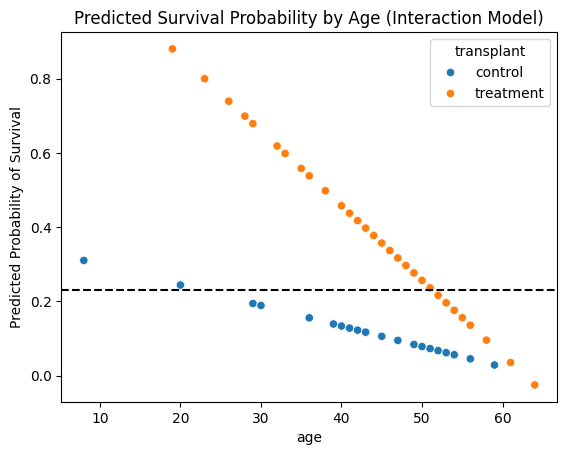

In [143]:
sns.scatterplot(data=df, x="age", y="predicted_interaction", hue="transplant")

plt.axhline(ATE, linestyle="--", color="black")

plt.title("Predicted Survival Probability by Age (Interaction Model)")
plt.ylabel("Predicted Probability of Survival")

plt.show()

4.4
Including the interaction term between transplant and age allows the effect of age on survival to differ between transplant recipients and control patients. In the previous model, the predicted survival curves were parallel, implying that age had the same effect regardless of transplant status. With the interaction term included, the slopes differ, showing that the effect of a transplant changes with age. The negative coefficient on the interaction term indicates that the survival benefit of a transplant decreases as age increases. The predicted survival curves show that younger patients benefit more from receiving a transplant, while the benefit becomes smaller for older patients.

In [144]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

In [145]:
X1 = df[["transplant_dummy"]]

In [146]:
X2 = df[["transplant_dummy","age"]]

In [147]:
X3 = df[["transplant_dummy","age","transplant_age"]]

In [148]:
model = LinearRegression()

scores1 = cross_val_score(model, X1, y, cv=10, scoring="r2")
scores2 = cross_val_score(model, X2, y, cv=10, scoring="r2")
scores3 = cross_val_score(model, X3, y, cv=10, scoring="r2")

print("Model 1 CV R2:", scores1.mean())
print("Model 2 CV R2:", scores2.mean())
print("Model 3 CV R2:", scores3.mean())

Model 1 CV R2: -0.4043912290011423
Model 2 CV R2: -0.4948327098378075
Model 3 CV R2: -0.49098773603660933


4.5
Using 10-fold cross validation, the predictive accuracy of the models was evaluated using the R² metric. All models produced negative cross-validated R² values, indicating that the models perform worse than simply predicting the average survival rate. Among the three models, the transplant-only model had the highest (least negative) R², while the models including age and the interaction term had slightly lower predictive accuracy. This suggests that adding age and the interaction term does not substantially improve predictive performance for this dataset.

4.6
If this model were used to prioritize access to heart transplants, there would be several concerns about both model construction and deployment. First, the model is based on a relatively small dataset and uses a simple linear regression on a binary outcome, which may not accurately capture the true factors influencing survival. Important variables such as overall health status, comorbidities, or lifestyle factors are not included, which could bias the predictions. There is also a risk that relying heavily on age in the model could disadvantage older patients, raising ethical concerns about fairness in allocating life-saving treatments. Additionally, predictive models can reinforce existing biases in the data if the training data reflects historical inequalities in access to care. For these reasons, such a model should only be used as one input among many clinical and ethical considerations rather than as the sole basis for transplant prioritization.